In [1]:
##comprobación
import sys
print(sys.executable)

/home/angel/projects/CNC_Project/venv/bin/python


In [2]:
##primera celda
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

RANDOM_STATE = 42

PROJECT_ROOT = Path("..").resolve() if Path.cwd().name == "notebooks" else Path(".").resolve()

DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
DOCS_DIR = PROJECT_ROOT / "docs"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)

DATASET_SCALED_PATH = DATA_DIR / "dataset_scaled.csv"
DATASET_ORIGINAL_PATH = DATA_DIR / "dataset.csv"

RF_MODEL_PATH = MODELS_DIR / "rf_model.pkl"
LABEL_ENCODER_PATH = MODELS_DIR / "label_encoder.pkl"

CONFUSION_MATRIX_PATH = FIGURES_DIR / "rf_confusion_matrix_base.png"
FEATURE_IMPORTANCE_PATH = FIGURES_DIR / "rf_feature_importance_top10.png"
CLASSIFICATION_DOC_PATH = DOCS_DIR / "classification_results_base.md"

print("Project root:", PROJECT_ROOT)
print("Scaled dataset exists:", DATASET_SCALED_PATH.exists(), DATASET_SCALED_PATH)
print("Original dataset exists:", DATASET_ORIGINAL_PATH.exists(), DATASET_ORIGINAL_PATH)

Project root: /home/angel/projects/CNC_Project
Scaled dataset exists: True /home/angel/projects/CNC_Project/data/processed/dataset_scaled.csv
Original dataset exists: True /home/angel/projects/CNC_Project/data/processed/dataset.csv


In [3]:
##cargar dataset
df_scaled = pd.read_csv(DATASET_SCALED_PATH)

if DATASET_ORIGINAL_PATH.exists():
    df_original = pd.read_csv(DATASET_ORIGINAL_PATH)
else:
    df_original = df_scaled.copy()

print("Scaled dataset shape:", df_scaled.shape)
print("Original dataset shape:", df_original.shape)

display(df_scaled.head())
display(df_scaled.dtypes)

Scaled dataset shape: (491, 29)
Original dataset shape: (491, 29)


,protocol,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,dst2src_packets,src2dst_bytes,dst2src_bytes,bidirectional_mean_ps,bidirectional_syn_packets,bidirectional_ack_packets,...,iat_mean_ms_missing,iat_std_ms_missing,iat_cv_missing,rtt_estimate_ms_missing,tcp_window_min_missing,tcp_window_max_missing,tcp_window_mean_missing,tcp_window_var_missing,syn_ack_ratio_manual_missing,label
0,0.996000,-0.549898,-1.258654,-1.391128,-1.221632,-1.078608,-1.221632,-1.253347,-1.074015,-1.074015,...,1.258654,1.258654,1.258654,0.499363,1.074015,1.074015,1.074015,1.074015,1.074015,udp_scan
1,-0.869255,1.818521,0.794499,1.229215,0.818577,1.545013,0.818577,1.265758,0.931085,0.931085,...,-0.794499,-0.794499,-0.794499,-2.002549,-0.931085,-0.931085,-0.931085,-0.931085,-0.931085,normal
2,0.996000,-0.549898,-1.258654,-1.391128,-1.221632,-1.078608,-1.221632,-1.253347,-1.074015,-1.074015,...,1.258654,1.258654,1.258654,0.499363,1.074015,1.074015,1.074015,1.074015,1.074015,udp_scan
3,0.996000,-0.549898,-1.258654,-1.391128,-1.221632,-1.078608,-1.221632,-1.253347,-1.074015,-1.074015,...,1.258654,1.258654,1.258654,0.499363,1.074015,1.074015,1.074015,1.074015,1.074015,udp_scan
4,0.996000,-0.549898,-1.258654,-1.391128,-1.221632,-1.078608,-1.221632,-1.253347,-1.074015,-1.074015,...,1.258654,1.258654,1.258654,0.499363,1.074015,1.074015,1.074015,1.074015,1.074015,udp_scan


protocol                          float64
bidirectional_duration_ms         float64
bidirectional_packets             float64
bidirectional_bytes               float64
dst2src_packets                   float64
src2dst_bytes                     float64
dst2src_bytes                     float64
bidirectional_mean_ps             float64
bidirectional_syn_packets         float64
bidirectional_ack_packets         float64
bidirectional_rst_packets         float64
bytes_asymmetry_ratio             float64
packets_asymmetry_ratio           float64
bidirectional_packets_per_ms      float64
bytes_per_packet                  float64
manual_packet_count               float64
iat_mean_ms                       float64
duration_zero_flag                float64
syn_ack_ratio_nfstream_missing    float64
iat_mean_ms_missing               float64
iat_std_ms_missing                float64
iat_cv_missing                    float64
rtt_estimate_ms_missing           float64
tcp_window_min_missing            

In [4]:
LABEL_COL = "label"

if LABEL_COL not in df_scaled.columns:
    raise ValueError(f"Column '{LABEL_COL}' not found in dataset_scaled.csv")

print("Label distribution:")
label_counts = df_scaled[LABEL_COL].value_counts()
label_percentages = df_scaled[LABEL_COL].value_counts(normalize=True).mul(100).round(2)

label_distribution = pd.DataFrame({
    "count": label_counts,
    "percentage": label_percentages
})

display(label_distribution)

Label distribution:


,count,percentage
label,,
udp_scan,129,26.27
normal,129,26.27
syn_scan,129,26.27
icmp_flood,61,12.42
port_sweep,43,8.76


In [5]:
non_feature_cols = {
    "label",
    "cluster",
    "flow_id",
    "id",
    "src_ip",
    "dst_ip",
    "src_port",
    "dst_port",
    "application_name",
    "application_category_name",
    "requested_server_name",
    "client_fingerprint",
    "server_fingerprint",
    "user_agent",
    "content_type",
    "pcap_file",
    "pcap_path",
    "filename",
    "timestamp",
    "bidirectional_first_seen_ms",
    "bidirectional_last_seen_ms",
}

numeric_cols = df_scaled.select_dtypes(include=[np.number]).columns.tolist()

feature_cols = [
    col for col in numeric_cols
    if col not in non_feature_cols
]

X = df_scaled[feature_cols].copy()
y_raw = df_scaled[LABEL_COL].copy()

print("Number of features:", len(feature_cols))
print("Features used:")
for col in feature_cols:
    print("-", col)

print("\nX shape:", X.shape)
print("y shape:", y_raw.shape)

Number of features: 28
Features used:
- protocol
- bidirectional_duration_ms
- bidirectional_packets
- bidirectional_bytes
- dst2src_packets
- src2dst_bytes
- dst2src_bytes
- bidirectional_mean_ps
- bidirectional_syn_packets
- bidirectional_ack_packets
- bidirectional_rst_packets
- bytes_asymmetry_ratio
- packets_asymmetry_ratio
- bidirectional_packets_per_ms
- bytes_per_packet
- manual_packet_count
- iat_mean_ms
- duration_zero_flag
- syn_ack_ratio_nfstream_missing
- iat_mean_ms_missing
- iat_std_ms_missing
- iat_cv_missing
- rtt_estimate_ms_missing
- tcp_window_min_missing
- tcp_window_max_missing
- tcp_window_mean_missing
- tcp_window_var_missing
- syn_ack_ratio_manual_missing

X shape: (491, 28)
y shape: (491,)


In [6]:
##sanity check
print("Any NaN in X?", X.isna().any().any())
print("Any infinite value in X?", np.isinf(X.to_numpy()).any())

display(X.describe().T[["mean", "std", "min", "max"]].round(4))

Any NaN in X? False
Any infinite value in X? False


,mean,std,min,max
protocol,0.0,1.001,-1.7171,7.9483
bidirectional_duration_ms,-0.0,1.001,-0.5499,1.8185
bidirectional_packets,-0.0,1.001,-1.2587,0.7945
bidirectional_bytes,-0.0,1.001,-1.3911,1.2292
dst2src_packets,0.0,1.001,-1.2216,0.8186
src2dst_bytes,0.0,1.001,-1.0786,1.5450
dst2src_bytes,-0.0,1.001,-1.2216,0.8186
bidirectional_mean_ps,-0.0,1.001,-1.2533,1.2658
bidirectional_syn_packets,0.0,1.001,-1.0740,0.9311
bidirectional_ack_packets,0.0,1.001,-1.0740,0.9311


In [7]:
## Label encoding

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

label_mapping = {
    class_name: int(encoded_value)
    for encoded_value, class_name in enumerate(label_encoder.classes_)
}

print("Label mapping:")
display(label_mapping)

joblib.dump(label_encoder, LABEL_ENCODER_PATH)
print("LabelEncoder saved to:", LABEL_ENCODER_PATH)

Label mapping:


{'icmp_flood': 0, 'normal': 1, 'port_sweep': 2, 'syn_scan': 3, 'udp_scan': 4}

LabelEncoder saved to: /home/angel/projects/CNC_Project/models/label_encoder.pkl


In [8]:
## Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

train_distribution = pd.Series(
    label_encoder.inverse_transform(y_train),
    name="label"
).value_counts().sort_index()

test_distribution = pd.Series(
    label_encoder.inverse_transform(y_test),
    name="label"
).value_counts().sort_index()

split_distribution = pd.DataFrame({
    "train_count": train_distribution,
    "test_count": test_distribution
})

display(split_distribution)

X_train shape: (392, 28)
X_test shape: (99, 28)


,train_count,test_count
label,,
icmp_flood,49,12
normal,103,26
port_sweep,34,9
syn_scan,103,26
udp_scan,103,26


In [9]:
## Train baseline Random Forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE
)

rf_model.fit(X_train, y_train)

print("Random Forest base model trained.")

Random Forest base model trained.


In [10]:
## Accuracy evaluation

y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
accuracy_gap = train_accuracy - test_accuracy

print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Test accuracy:  {test_accuracy:.4f}")
print(f"Accuracy gap:   {accuracy_gap:.4f}")

Train accuracy: 0.9796
Test accuracy:  0.9697
Accuracy gap:   0.0099


In [11]:
## Classification report

target_names = label_encoder.classes_

report_dict = classification_report(
    y_test,
    y_test_pred,
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

report_text = classification_report(
    y_test,
    y_test_pred,
    target_names=target_names,
    zero_division=0
)

print(report_text)

report_df = pd.DataFrame(report_dict).T
display(report_df.round(4))

              precision    recall  f1-score   support

  icmp_flood       0.92      1.00      0.96        12
      normal       1.00      0.96      0.98        26
  port_sweep       1.00      0.78      0.88         9
    syn_scan       0.93      1.00      0.96        26
    udp_scan       1.00      1.00      1.00        26

    accuracy                           0.97        99
   macro avg       0.97      0.95      0.96        99
weighted avg       0.97      0.97      0.97        99



,precision,recall,f1-score,support
icmp_flood,0.9231,1.0000,0.9600,12.0000
normal,1.0000,0.9615,0.9804,26.0000
port_sweep,1.0000,0.7778,0.8750,9.0000
syn_scan,0.9286,1.0000,0.9630,26.0000
udp_scan,1.0000,1.0000,1.0000,26.0000
accuracy,0.9697,0.9697,0.9697,0.9697
macro avg,0.9703,0.9479,0.9557,99.0000
weighted avg,0.9719,0.9697,0.9689,99.0000


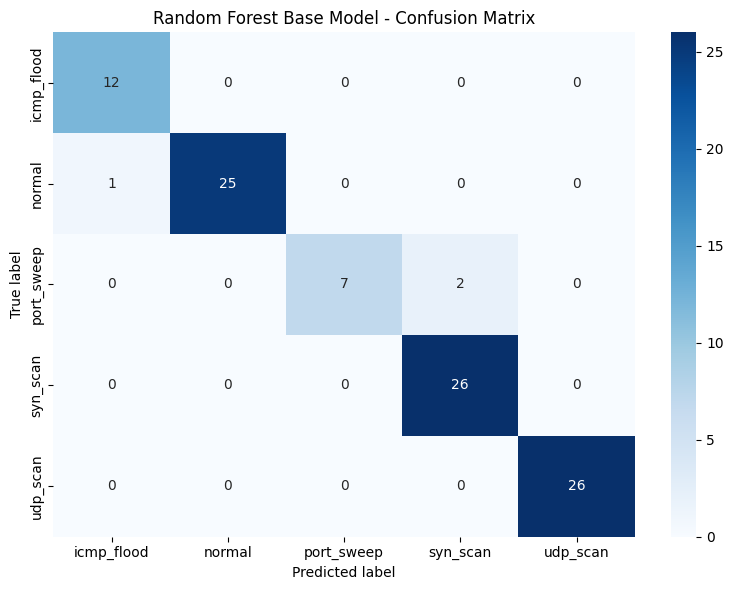

Confusion matrix saved to: /home/angel/projects/CNC_Project/reports/figures/rf_confusion_matrix_base.png


In [12]:
## Confusion matrix

cm = confusion_matrix(y_test, y_test_pred)

cm_df = pd.DataFrame(
    cm,
    index=target_names,
    columns=target_names
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Random Forest Base Model - Confusion Matrix")
plt.tight_layout()

plt.savefig(CONFUSION_MATRIX_PATH, dpi=300)
plt.show()

print("Confusion matrix saved to:", CONFUSION_MATRIX_PATH)

In [13]:
## Feature importance

feature_importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

display(feature_importances.head(15).round(4))

,feature,importance
5,src2dst_bytes,0.1699
16,iat_mean_ms,0.1456
14,bytes_per_packet,0.1291
7,bidirectional_mean_ps,0.1190
3,bidirectional_bytes,0.1142
10,bidirectional_rst_packets,0.0455
21,iat_cv_missing,0.0304
12,packets_asymmetry_ratio,0.0269
4,dst2src_packets,0.0268
20,iat_std_ms_missing,0.0248


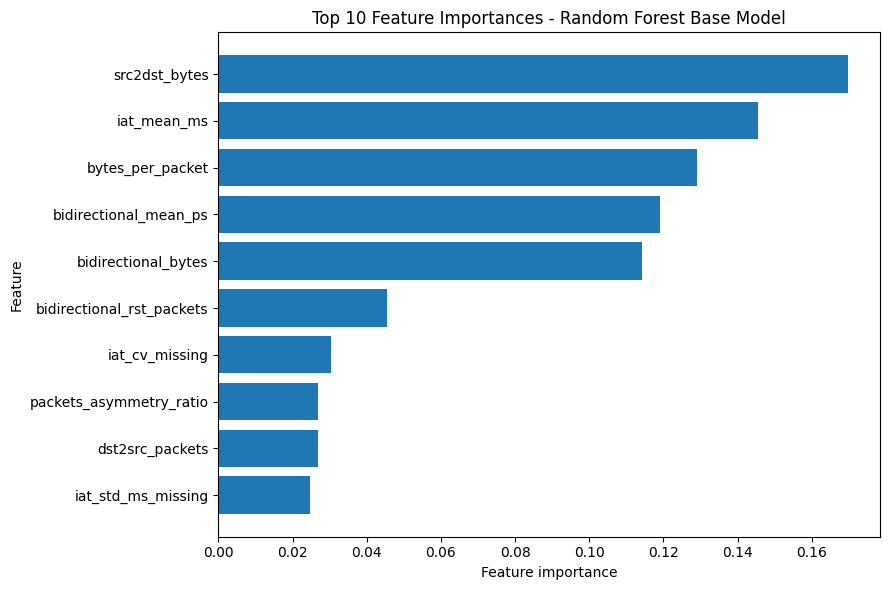

Feature importance plot saved to: /home/angel/projects/CNC_Project/reports/figures/rf_feature_importance_top10.png


In [14]:
## Top 10 feature importance plot

top_n = 10
top_features = feature_importances.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Random Forest Base Model")
plt.tight_layout()

plt.savefig(FEATURE_IMPORTANCE_PATH, dpi=300)
plt.show()

print("Feature importance plot saved to:", FEATURE_IMPORTANCE_PATH)

In [15]:
## Save model

joblib.dump(rf_model, RF_MODEL_PATH)

print("Random Forest model saved to:", RF_MODEL_PATH)
print("LabelEncoder saved to:", LABEL_ENCODER_PATH)

Random Forest model saved to: /home/angel/projects/CNC_Project/models/rf_model.pkl
LabelEncoder saved to: /home/angel/projects/CNC_Project/models/label_encoder.pkl


In [16]:
## Save metrics as JSON

metrics = {
    "model": "RandomForestClassifier",
    "type": "base",
    "random_state": RANDOM_STATE,
    "n_estimators": 100,
    "train_accuracy": float(train_accuracy),
    "test_accuracy": float(test_accuracy),
    "accuracy_gap": float(accuracy_gap),
    "label_mapping": label_mapping,
    "features": feature_cols,
    "classification_report": report_dict,
    "top_10_features": feature_importances.head(10).to_dict(orient="records")
}

metrics_path = DOCS_DIR / "rf_base_metrics.json"

with metrics_path.open("w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print("Metrics saved to:", metrics_path)

Metrics saved to: /home/angel/projects/CNC_Project/docs/rf_base_metrics.json


In [17]:
## Generate classification results document

lines = []

lines.append("# Random Forest Base Classification Results\n")

lines.append("## Model configuration\n")
lines.append("- Model: `RandomForestClassifier`\n")
lines.append("- Number of trees: `n_estimators=100`\n")
lines.append(f"- Random state: `{RANDOM_STATE}`\n")
lines.append("- Train/test split: 80/20 stratified by label\n")

lines.append("## Why Random Forest?\n")
lines.append(
    "Random Forest is suitable for this network traffic classification task because "
    "(1) it handles heterogeneous numerical features without requiring strict distributional assumptions, "
    "(2) it is robust to irrelevant or weak features because they tend to receive low importance, "
    "(3) its ensemble nature reduces overfitting compared with a single decision tree, and "
    "(4) its built-in feature importance allows validating whether the most discriminative features "
    "match the expected TCP/IP protocol behavior.\n"
)

lines.append("## Dataset and labels\n")
lines.append("The dataset contains five traffic classes: `normal`, `icmp_flood`, `syn_scan`, `udp_scan` and `port_sweep`.\n")
lines.append("Label distribution:\n")
lines.append(label_distribution.to_markdown())
lines.append("\n")

lines.append("## Train/test distribution\n")
lines.append(split_distribution.to_markdown())
lines.append("\n")

lines.append("## Accuracy\n")
lines.append(f"- Train accuracy: `{train_accuracy:.4f}`\n")
lines.append(f"- Test accuracy: `{test_accuracy:.4f}`\n")
lines.append(f"- Accuracy gap: `{accuracy_gap:.4f}`\n")

lines.append("## Classification report\n")
lines.append(report_df.round(4).to_markdown())
lines.append("\n")

lines.append("## Confusion matrix\n")
lines.append(f"Saved figure: `{CONFUSION_MATRIX_PATH.relative_to(PROJECT_ROOT)}`\n")

lines.append("## Top 10 feature importances\n")
lines.append(feature_importances.head(10).round(4).to_markdown(index=False))
lines.append("\n")

lines.append("## Preliminary technical interpretation\n")
lines.append(
    "The feature importance ranking must be interpreted from a protocol perspective. "
    "If protocol, TCP flag counts, duration, packet size, packet rate, asymmetry ratios or missingness indicators "
    "appear among the most important variables, the model is learning L3/L4 behavior instead of inspecting payload. "
    "This is aligned with the project goal: classifying traffic using flow-level metadata only.\n"
)

CLASSIFICATION_DOC_PATH.write_text("\n".join(lines), encoding="utf-8")

print("Classification summary saved to:", CLASSIFICATION_DOC_PATH)

Classification summary saved to: /home/angel/projects/CNC_Project/docs/classification_results_base.md
